# Exploring Chant Sources with PyCantus

**Workshop Notebook 1 of 2**

This notebook introduces the **PyCantus** library for working with medieval chant data from the [Cantus Database](https://cantusdatabase.org/). We will:

1. Load a chant corpus from CSV files
2. Inspect sources (manuscripts)
3. Collect chants belonging to a specific source
4. Explore genres and feast names
5. Build summary DataFrames with Pandas

---

### Background: The Cantus Data Model

| Term | Meaning |
|---|---|
| **Source** | A physical manuscript or printed book containing chants |
| **Chant** | One occurrence of a chant in a source, with text and (optionally) a melody |
| **Corpus** | A collection of sources and chants, loaded from CSV |
| **Volpiano** | A text-based encoding of a chant melody |
| **Genre** | The liturgical type of a chant (A = Antiphon, R = Responsory, etc.) |

---

## 1. Installation & Imports

In [ ]:
# Run this cell once to install PyCantus
# (Skip if already installed)
!pip install git+https://github.com/dact-chant/PyCantus.git -q

In [ ]:
import pandas as pd

import plotly.express as px
import re
import numpy as np

from pycantus.models import Corpus

# Quick sanity check
from pycantus import hello_pycantus
hello_pycantus()


    *********************************************
    *                                           *
    *           Welcome to PyCantus!            *
    *                                           *
    *    A Python library designed to enhance   *
    *    accessibility of Gregorian chants for  *
    *    both coders and non-coders.            *
    *                                           *
    *********************************************
    


---
## 2. Loading the Sample Corpus

A **Corpus** is loaded from two CSV files:
- `chants.csv` — one row per chant occurrence
- `sources.csv` — one row per manuscript source

The [CantusCorpus v1.0](https://github.com/DvorakovaA/CantusCorpus) dataset is the recommended starting point.

The cell below creates a `./cantus_data/` folder next to your notebook and downloads the CSV files there automatically if they are not already present. **If you already have the files**, just set `DATA_DIR` to the folder that contains them and the download step is skipped.

In [95]:
import os

# -------------------------------------------------------------------
# Data directory — CSV files will be downloaded here if not present.
# Change DATA_DIR to any folder you prefer.
# -------------------------------------------------------------------
DATA_DIR = './cantus_data'
os.makedirs(DATA_DIR, exist_ok=True)

CHANTS_FILE  = os.path.join(DATA_DIR, 'chants.csv')
SOURCES_FILE = os.path.join(DATA_DIR, 'sources.csv')

# -------------------------------------------------------------------
# Option A: Already have local files? Set DATA_DIR above to their folder.
# Option B: No files yet? PyCantus will auto-download CantusCorpus v1.0.
#   Requires internet access; the full corpus is ~50 MB.
# -------------------------------------------------------------------
CHANTS_URL  = 'https://raw.githubusercontent.com/dact-chant/PyCantus/refs/heads/main/pycantus/dataset_files/sample_dataset/chants.csv'
SOURCES_URL = 'https://raw.githubusercontent.com/dact-chant/PyCantus/refs/heads/main/pycantus/dataset_files/sample_dataset/sources.csv'

corpus = Corpus(
    chants_filepath=CHANTS_FILE,
    sources_filepath=SOURCES_FILE,
    chants_fallback_url=CHANTS_URL,
    sources_fallback_url=SOURCES_URL,
    create_missing_sources=True,   # tolerate chants whose source isn't listed
)

print(f"Loaded {len(corpus.chants):,} chants from {len(corpus.sources):,} sources.")

Loading chants and sources...
Creating missing sources...
1 missing sources created!
Data loaded!
Loaded 100 chants from 79 sources.


---
## 3. Inspecting Sources

Each `Source` object has these key attributes:

| Attribute | Description |
|---|---|
| `siglum` | Short manuscript identifier (e.g. `"A-Wn 1799"`) |
| `title` | Full title of the manuscript |
| `century` | Century of origin (e.g. `"12"`) |
| `provenance` | Place of origin |
| `cursus` | Secular or Monastic |
| `srclink` | URL in the Cantus Database |

In [96]:
# Build a DataFrame of all sources for easy browsing
sources_df = pd.DataFrame([
    {
        'siglum':    s.siglum,
        'title':     s.title,
        'century':   s.century,
        'provenance': s.provenance,
        'cursus':    s.cursus,
        'srclink':   s.srclink,
    }
    for s in corpus.sources
])

print(f"Shape: {sources_df.shape}")
sources_df.head(10)

Shape: (79, 6)


,siglum,title,century,provenance,cursus,srclink
0,A-Gu 29 (olim 38/8 f.),"Graz, Universitätsbibliothek, 29 (olim 38/8 f.)",14th century,St-Lambrecht,Monastic,https://cantusdatabase.org/source/123610
1,A-Gu 30 (olim 38/9 f.),"Graz, Universitätsbibliothek, 30 (olim 38/9 f.)",14th century,St-Lambrecht,Monastic,https://cantusdatabase.org/source/123611
2,A-LIb 290 (olim 183; olim Gamma p 19),"Linz, Oberösterreichische Landesbibliothek, 29...",12th century,Kremsmünster,Monastic,https://cantusdatabase.org/source/123617
3,A-Wn Cod. 1890,"Wien, Österreichische Nationalbibliothek, Cod....",12th century,Southern Germany / Austria,Monastic,https://cantusdatabase.org/source/123713
4,CH-E 611,"Einsiedeln, Stiftsbibliothek, 611",14th century,Einsiedeln,Monastic,https://cantusdatabase.org/source/123606
5,CZ-Pu XIV C 20,CZ-Pu (Praha) XIV C 20,14th century,St George's Convent in Prague,None,https://cantusbohemiae.cz/source/9137
6,CZ-Pu VI.E.4c,"Prague, Národní knihovna České republiky (Nati...",12th century (2nd half),"Prague, St. George Monastery",Monastic,https://cantusdatabase.org/source/123727
7,CZ-Pu XIV.B.13,"Prague, Národní knihovna České republiky (Nati...",14th century,"Prague, St. George Monastery",None,https://cantusdatabase.org/source/123730
8,D-KA Aug. LX,"Karlsruhe, Badische Landesbibliothek - Musiksa...",12th century,Zwiefalten,Monastic,https://cantusdatabase.org/source/123612
9,D-Sl HB.I.55,"Stuttgart, Württembergische Landesbibliothek, ...",12th century,Weingarten,Monastic,https://cantusdatabase.org/source/123637


In [97]:
# what does one record look like?
print(sources_df.iloc[0])

siglum                                 A-Gu 29 (olim 38/8 f.)
title         Graz, Universitätsbibliothek, 29 (olim 38/8 f.)
century                                          14th century
provenance                                       St-Lambrecht
cursus                                               Monastic
srclink              https://cantusdatabase.org/source/123610
Name: 0, dtype: object


In [98]:
# How many sources per century?
century_counts = (
    sources_df['century']
    .dropna()
    .astype(str)
    .value_counts()
    .sort_index()
)
century_counts

century
10th century                 2
10th century (975-1000)      2
11th century                 4
11th century (1000-1025)     1
11th century (1075-1100)     1
12th century                17
12th century (1175-1200)     1
12th century (2nd half)      2
13th century                 8
13th century (1225-1250)     3
13th century (2nd half)      2
14th century                14
14th century (1375-1400)     2
15th century                 6
15th century (1425-1450)     1
16th century                 1
16th century (1500-1525)     2
16th century (1550-1575)     1
16th century (1575-1600)     1
16th century (2nd half)      1
9th century                  2
Name: count, dtype: int64

## Data Cleaning: Parsing Century Strings and Extracting Country Codes

In [106]:
# the sigla have a lot of information in them 
sources_df['siglum'].value_counts().head(10)

siglum
A-Gu 29 (olim 38/8 f.)               1
E-H Ms. 2                            1
F-AI 44                              1
E-VI Mss. 113-114                    1
E-Tc 44.2                            1
E-Tc 44.1                            1
E-SI MS 9                            1
E-PAMan Partitura n. 116             1
E-H Ms. 7 (ant. 5)                   1
E-Gs ms. 45 (olim Sant Feliu, 20)    1
Name: count, dtype: int64

In [ ]:
# extract a country code from siglum for easier grouping
sources_df['country'] = sources_df['siglum'].str.split('-').str[0]

In [100]:
# let's deal with the century column a bit more — what values does it actually have?
sources_df['century'].unique()

array(['14th century', '12th century', '12th century (2nd half)',
       '9th century', '13th century', '13th century (2nd half)',
       '15th century', '16th century (2nd half)',
       '14th century (1375-1400)', '16th century (1550-1575)', None,
       '10th century (975-1000)', '11th century',
       '15th century (1425-1450)', '13th century (1225-1250)',
       '16th century (1500-1525)', '16th century',
       '16th century (1575-1600)', '11th century (1000-1025)',
       '11th century (1075-1100)', '10th century',
       '12th century (1175-1200)'], dtype=object)

In [107]:


# Map ordinal century strings to century numbers
ORDINAL_MAP = {
    '9th': 9, '10th': 10, '11th': 11, '12th': 12,
    '13th': 13, '14th': 14, '15th': 15, '16th': 16,
    '17th': 17, '18th': 18
}

# function to parse century strings into structured date fields
def parse_century_string(s):
    """
    Parse a Cantus century string into structured date fields.
    
    Returns a dict with:
      century_num   : int        e.g. 14
      date_start    : int        e.g. 1300
      date_end      : int        e.g. 1399
      date_mid      : float      e.g. 1349.5  (for sorting/plotting)
      date_label    : str        e.g. '1300–1399'
    All fields are None if input is None or unparseable.
    """
    if not s:
        return dict(century_num=None, date_start=None,
                    date_end=None, date_mid=None, date_label=None)

    # Century base (always present)
    century_match = re.match(r'(\d+th|\d+st|\d+nd|\d+rd) century', s)
    if not century_match:
        return dict(century_num=None, date_start=None,
                    date_end=None, date_mid=None, date_label=None)

    century_word = century_match.group(1)
    c = ORDINAL_MAP.get(century_word)
    if c is None:
        return dict(century_num=None, date_start=None,
                    date_end=None, date_mid=None, date_label=None)

    century_start = (c - 1) * 100   # e.g. 13th → 1200
    century_end   = century_start + 99

    # Default to full century range
    date_start, date_end = century_start, century_end

    # Check for parenthetical qualifier
    paren = re.search(r'\((.+?)\)', s)
    if paren:
        qualifier = paren.group(1)

        # Specific year range: (1375-1400)
        year_range = re.match(r'(\d{4})\s*[-–]\s*(\d{4})', qualifier)
        if year_range:
            date_start = int(year_range.group(1))
            date_end   = int(year_range.group(2))

        # Half-century: (1st half) or (2nd half)
        elif '1st half' in qualifier:
            date_end = century_start + 49
        elif '2nd half' in qualifier:
            date_start = century_start + 50

        # Quarter hints (less common but just in case)
        elif '1st quarter' in qualifier:
            date_end = century_start + 24
        elif '2nd quarter' in qualifier:
            date_start = century_start + 25
            date_end   = century_start + 49
        elif '3rd quarter' in qualifier:
            date_start = century_start + 50
            date_end   = century_start + 74
        elif '4th quarter' in qualifier:
            date_start = century_start + 75

    date_mid   = (date_start + date_end) / 2
    date_label = f'{date_start}–{date_end}'

    return dict(
        century_num=c,
        date_start=date_start,
        date_end=date_end,
        date_mid=date_mid,
        date_label=date_label,
    )


# Apply to the sources DataFrame
parsed = sources_df['century'].apply(parse_century_string).apply(pd.Series)
sources_df = pd.concat([sources_df, parsed], axis=1)

# clean up column order for easier browsing
sources_df[['siglum', 'country', 'century', 'date_label', 'date_start', 'date_end', 'date_mid']].head(20)
sources_df

,siglum,title,century,provenance,cursus,srclink,century_num,date_start,date_end,date_mid,...,century_num,date_start,date_end,date_mid,date_label,century_num,date_start,date_end,date_mid,date_label
0,A-Gu 29 (olim 38/8 f.),"Graz, Universitätsbibliothek, 29 (olim 38/8 f.)",14th century,St-Lambrecht,Monastic,https://cantusdatabase.org/source/123610,14.0,1300.0,1399.0,1349.5,...,14.0,1300.0,1399.0,1349.5,1300–1399,14.0,1300.0,1399.0,1349.5,1300–1399
1,A-Gu 30 (olim 38/9 f.),"Graz, Universitätsbibliothek, 30 (olim 38/9 f.)",14th century,St-Lambrecht,Monastic,https://cantusdatabase.org/source/123611,14.0,1300.0,1399.0,1349.5,...,14.0,1300.0,1399.0,1349.5,1300–1399,14.0,1300.0,1399.0,1349.5,1300–1399
2,A-LIb 290 (olim 183; olim Gamma p 19),"Linz, Oberösterreichische Landesbibliothek, 29...",12th century,Kremsmünster,Monastic,https://cantusdatabase.org/source/123617,12.0,1100.0,1199.0,1149.5,...,12.0,1100.0,1199.0,1149.5,1100–1199,12.0,1100.0,1199.0,1149.5,1100–1199
3,A-Wn Cod. 1890,"Wien, Österreichische Nationalbibliothek, Cod....",12th century,Southern Germany / Austria,Monastic,https://cantusdatabase.org/source/123713,12.0,1100.0,1199.0,1149.5,...,12.0,1100.0,1199.0,1149.5,1100–1199,12.0,1100.0,1199.0,1149.5,1100–1199
4,CH-E 611,"Einsiedeln, Stiftsbibliothek, 611",14th century,Einsiedeln,Monastic,https://cantusdatabase.org/source/123606,14.0,1300.0,1399.0,1349.5,...,14.0,1300.0,1399.0,1349.5,1300–1399,14.0,1300.0,1399.0,1349.5,1300–1399
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,GB-Lbl Add MS 30848,GB-Lbl (London) Add MS 30848,11th century,Santo Domingo de Silos,Monastic,https://musicahispanica.eu/source/74655,11.0,1000.0,1099.0,1049.5,...,11.0,1000.0,1099.0,1049.5,1000–1099,11.0,1000.0,1099.0,1049.5,1000–1099
75,GB-Lbl Add MS 30850,GB-Lbl (London) Add MS 30850,11th century,Ascribed to Santo Domingo de Silos (see 'Descr...,Monastic,https://musicahispanica.eu/source/20199,11.0,1000.0,1099.0,1049.5,...,11.0,1000.0,1099.0,1049.5,1000–1099,11.0,1000.0,1099.0,1049.5,1000–1099
76,GB-Ob MS. Laud Misc. 284,"Oxford, Bodleian Library, MS. Laud Misc. 284",12th century,Würzburg,Secular,https://cantusdatabase.org/source/123707,12.0,1100.0,1199.0,1149.5,...,12.0,1100.0,1199.0,1149.5,1100–1199,12.0,1100.0,1199.0,1149.5,1100–1199
77,GB-WO F. 160 (olim 1247) (with hymnal),"Worcester, Cathedral - Music Library, F. 160 (...",13th century (1225-1250),Worcester,Monastic,https://cantusdatabase.org/source/123647,13.0,1225.0,1250.0,1237.5,...,13.0,1225.0,1250.0,1237.5,1225–1250,13.0,1225.0,1250.0,1237.5,1225–1250


In [103]:

sources_grouped = (
    sources_df
    .groupby(['date_label', 'country', 'century_num', 'date_start'])
    .size()
    .reset_index(name='count')
    .sort_values(['century_num', 'date_start'])
)

fig = px.bar(sources_grouped,
             x='date_label',
             y='count',
             color='country',
             title='Sources by Date',
             width=800, height=400)

# Tell Plotly to keep the x-axis order as-is (don't re-sort alphabetically)
fig.update_xaxes(categoryorder='array', categoryarray=sources_grouped['date_label'].tolist())

fig.show()

---
## 4. Selecting a Single Source

Pick a source by its **siglum** (the short manuscript code).  
Change `TARGET_SIGLUM` to any siglum you see in the table above.

In [ ]:
# Choose a source to explore

TARGET_SIGLUM = 'CH-SGs 390' # <-- change this!
print(f"Exploring source: {TARGET_SIGLUM}")

Exploring source: CH-SGs 390


In [30]:
# Collect all chants from that source into a list
source_chants = [
    c for c in corpus.chants
    if c.siglum == TARGET_SIGLUM
]

print(f"Found {len(source_chants)} chants in '{TARGET_SIGLUM}'")

Found 2178 chants in 'CH-SGs 390'


In [108]:
source_chants

 ...]

In [40]:
# Check the exact siglum string
print(repr(TARGET_SIGLUM))

# See what sigla actually appear in the chants
chant_sigla = set(c.siglum for c in corpus.chants)
print(f"\nTotal unique sigla in chants: {len(chant_sigla)}")



'CH-SGs 390'

Total unique sigla in chants: 2280


In [27]:
from pycantus.models import Corpus
from pycantus.data import load_dataset

# -------------------------------------------------------------------
# Option A (workshop/quick start): the built-in 100-chant sample
#   → good for testing code, but only 1–2 chants per source
# -------------------------------------------------------------------
# corpus = load_dataset('sample_dataset')

# -------------------------------------------------------------------
# Option B (recommended): CantusCorpus v1.0  
#   → ~500k chants from 79 fully-indexed sources
#   → downloads ~50 MB on first run, cached locally after that
# -------------------------------------------------------------------
corpus = load_dataset('cantuscorpus_v1.0')

print(f"Loaded {len(corpus.chants):,} chants from {len(corpus.sources):,} sources.")

Loading chants and sources...
Data loaded!
Loaded 888,010 chants from 2,278 sources.


In [63]:
sources_df = pd.DataFrame([vars(s) for s in corpus.sources]).drop(columns=['locked'])
sources_df['country'] = sources_df['siglum'].str.split('-').str[0]
countries_counts = sources_df.groupby(['country'])['century'].size()
countries_counts
# fig = px.bar(countries_counts, 
#              x=title="Sources per Country")
# fig.update_layout(xaxis_title="Country", yaxis_title="Number of Sources")
# fig.show()

country
A                                                                  180
AUS                                                                  3
Antifonario s.s.                                                     1
B                                                                    9
CDN                                                                 51
CH                                                                  43
CZ                                                                 100
CZ–Pn XIII B 2                                                       1
CZ–Pu I D 33                                                         1
Cantoral Anchuelo, Iglesia de Santa María Magdalena, cantoral 1      1
Cantus D:01oko                                                       1
Cantus D:02csu                                                       1
Cantus D:04sqa                                                       1
Cantus D:07lvz                                                       

---
## 5. Building a Chant DataFrame

We turn the list of `Chant` objects into a Pandas DataFrame.  
This makes it easy to sort, filter, and visualise the data.

In [109]:
# Key chant fields
CHANT_FIELDS = [
    'cantus_id', 'incipit', 'feast', 'genre',
    'office', 'position', 'mode', 'folio',
    'sequence', 'melody', 'chantlink'
]

def chant_to_dict(c):
    """Convert a Chant object to a plain dictionary."""
    return {field: getattr(c, field, None) for field in CHANT_FIELDS}

chants_df = pd.DataFrame([chant_to_dict(c) for c in source_chants])
print(f"DataFrame shape: {chants_df.shape}")
chants_df.head()

DataFrame shape: (2178, 11)


,cantus_id,incipit,feast,genre,office,position,mode,folio,sequence,melody,chantlink
0,004025,O Emmanuel rex et legifer,Antiphonae Majores,A,V,7M,2,041,None,None,https://cantusdatabase.org/chant/456196
1,003044,Hi sunt qui cum mulieribus,Nat. Innocentium,A,L,1B,1,068,None,None,https://cantusdatabase.org/chant/456503
2,005350,Venite benedicti patris mei percipite,Fer. 2 Hebd. 1 Quad.,A,E,1,7,148,None,None,https://cantusdatabase.org/chant/457544
3,005234,Tulerunt lapides ut jacerent in,Dom. de Passione,A,E,5,7,168,None,None,https://cantusdatabase.org/chant/457760
4,001466,Apud dominum misericordia et copiosa,Nativitas Domini,A,V2,4,4,052,None,None,https://cantusdatabase.org/chant/456313


In [110]:
# Source: https://cantusdatabase.org/services/
OFFICE_NAMES = {
    '?':  'Unknown',
    'C':  'Compline',
    'CA': 'Chapter',
    'D':  'Day Hours',
    'E':  'Antiphons for Magnificat or Benedictus (in evangelio)',
    'H':  'Antiphons from the Historia',
    'L':  'Lauds',
    'M':  'Matins',
    'MI': 'Mass',
    'N':  'None',
    'P':  'Prime',
    'R':  'Memorial',
    'S':  'Sext',
    'T':  'Terce',
    'V':  'First Vespers',
    'V2': 'Second Vespers',
    'X':  'Supplemental / Unclear',
}

# Apply to your chants DataFrame
chants_df['office_name'] = chants_df['office'].map(OFFICE_NAMES).fillna('Unknown')

In [112]:

# Quick summary of missing values
chant_office_mode_groups = chants_df.groupby(['office_name', 'mode']).size()

fig = px.bar(
    chant_office_mode_groups.reset_index(name='count'),
    x='mode',
    y='count',
    color='office_name',
    title=f"Chants in {TARGET_SIGLUM} by Office and Mode",
    width=800,
    height=600,)
fig.show()

---
## 6. Exploring Genres

Cantus uses single-letter genre codes. Common ones:

| Code | Genre |
|---|---|
| A | Antiphon |
| R | Responsory |
| V | Verse (of a Responsory) |
| H | Hymn |
| W | Versicle |
| I | Invitatory |
| G | Gradual |
| Of | Offertory |
| Co | Communion |

In [42]:
# Map genre codes to readable names
GENRE_NAMES = {
    'A': 'Antiphon',
    'R': 'Responsory',
    'V': 'Verse',
    'H': 'Hymn',
    'W': 'Versicle',
    'I': 'Invitatory',
    'G': 'Gradual',
    'Of': 'Offertory',
    'Co': 'Communion',
    'Gr': 'Gradual Verse',
    'Tr': 'Tract',
    'Al': 'Alleluia',
}

chants_df['genre_name'] = chants_df['genre'].map(GENRE_NAMES).fillna(chants_df['genre'])

# Count by genre
genre_counts = chants_df['genre_name'].value_counts()
print(genre_counts)

genre_name
Antiphon      1112
Responsory     486
Verse          466
Versicle        73
Invitatory      27
AV               6
Tp               6
Va               2
Name: count, dtype: int64


In [45]:
# Bar chart of genres
fig = px.scatter(chants_df, x='genre_name', y='cantus_id', title=f"Chant Genres in {TARGET_SIGLUM}")
fig.show()

---
## 7. Exploring Feasts and Chant Titles

The `incipit` is the opening phrase of the chant text — effectively its title.  
The `feast` field gives the liturgical occasion.

In [46]:
# Most common feast names
feast_counts = chants_df['feast'].value_counts().head(15)
print("Top 15 feasts:")
print(feast_counts)

Top 15 feasts:
feast
Nativitas Domini        109
Dom. per annum           98
Epiphania                87
Annuntiatio Mariae       79
Dom. in Palmis           69
Dom. de Passione         68
Dom. 1 Quadragesimae     61
Stephani                 61
Nat. Innocentium         59
Purificatio Mariae       56
Joannis Evang.           56
Fer. 5 in Cena Dom.      54
Agnetis                  54
Agathae                  52
Benedicti                52
Name: count, dtype: int64


In [47]:
# Show chant titles (incipits) for a specific feast
# Change this to any feast name you see above
SELECTED_FEAST = feast_counts.index[0]

feast_chants = chants_df[chants_df['feast'] == SELECTED_FEAST]

print(f"Chants for feast: '{SELECTED_FEAST}'  ({len(feast_chants)} total)\n")
feast_chants[['genre_name', 'incipit', 'mode', 'folio']].to_string(index=False)

Chants for feast: 'Nativitas Domini'  (109 total)



'genre_name                                      incipit mode folio\n  Antiphon        Apud dominum misericordia et copiosa     4   052\n  Antiphon       Notum fecit dominus alleluia salutare     6   046\n  Antiphon             Verbum caro factum est alleluia     6   047\n  Antiphon             Angelus ad pastores ait annuntio    7   050\n  Antiphon            Ipse invocabit me alleluia pater     6   046\n  Antiphon               Natus est nobis hodie salvator    8   047\n  Antiphon               Natus est nobis salvator mundi    8   053\n  Antiphon                        Homo natus est in ea     7   046\n  Antiphon                  Rex omnis terrae deus venit    8   044\n  Antiphon  Pastores loquebantur ad invicem transeamus     7   054\n  Antiphon                Diffusa est gratia in labiis     1   044\n  Antiphon     Gaudeamus omnes fideles salvator noster     6   051\n  Antiphon             Parvulus filius hodie natus est     8   051\n  Antiphon          Pastores dicite quidnam vid

In [48]:
# Cross-tabulation: genres × top feasts
top_feasts = feast_counts.index[:8].tolist()
cross_tab = (
    chants_df[chants_df['feast'].isin(top_feasts)]
    .groupby(['feast', 'genre_name'])
    .size()
    .unstack(fill_value=0)
)
cross_tab

genre_name,AV,Antiphon,Invitatory,Responsory,Tp,Va,Verse,Versicle
feast,,,,,,,,
Annuntiatio Mariae,1,49,0,13,3,0,13,0
Dom. 1 Quadragesimae,3,19,1,15,0,0,15,8
Dom. de Passione,0,15,1,22,0,0,22,8
Dom. in Palmis,1,27,1,23,0,0,17,0
Dom. per annum,0,23,0,32,0,0,32,11
Epiphania,0,42,1,19,0,1,18,6
Nativitas Domini,0,47,1,24,0,1,28,8
Stephani,0,35,1,13,0,0,12,0


---
## 8. Modal Distribution

Medieval chant is classified into 8 **modes** (musical scales).  
Modes 1–4 are *authentic*; modes 5–8 are *plagal*.

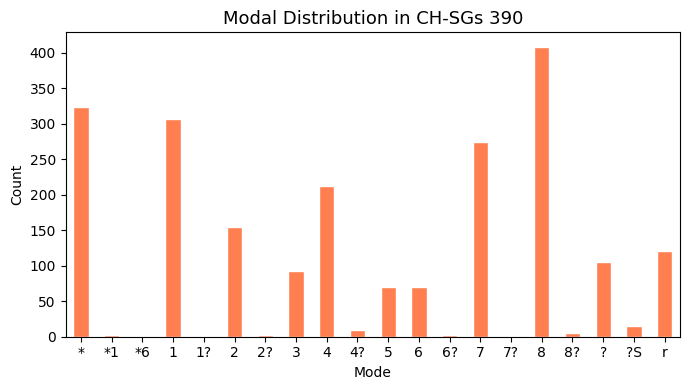

In [49]:
mode_counts = (
    chants_df['mode']
    .dropna()
    .value_counts()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(7, 4))
mode_counts.plot(kind='bar', ax=ax, color='coral', edgecolor='white')
ax.set_title(f'Modal Distribution in {TARGET_SIGLUM}', fontsize=13)
ax.set_xlabel('Mode')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

---
## 9. Chants with Melodies

Not all chants in the database have a melody encoded in Volpiano.  
Let's see how many do in our source.

In [50]:
has_melody = chants_df['melody'].notna()
print(f"Chants with melody:    {has_melody.sum()} ({has_melody.mean()*100:.1f}%)")
print(f"Chants without melody: {(~has_melody).sum()}")

Chants with melody:    0 (0.0%)
Chants without melody: 2178


In [51]:
# Preview the Volpiano strings for the first few chants that have one
melody_sample = chants_df[has_melody][['incipit', 'genre_name', 'mode', 'melody']].head(5)
melody_sample

,incipit,genre_name,mode,melody


---
## 10. Exporting Results

Save the DataFrame to CSV for further analysis.

In [ ]:
safe_siglum = TARGET_SIGLUM.replace(' ', '_').replace('/', '-')
output_filename = os.path.join(DATA_DIR, f"chants_{safe_siglum}.csv")
chants_df.to_csv(output_filename, index=False)
print(f"Saved to: {output_filename}")

---
## Summary

In this notebook you learned how to:

- Load a PyCantus `Corpus` from CSV files
- Browse `Source` metadata
- Filter chants by source siglum
- Build a Pandas DataFrame from `Chant` objects
- Explore genres, feast names, and modes with counts and charts
- Identify chants that have Volpiano melodies

➡️ Continue to **Notebook 2** to learn how to decode Volpiano melodies into tabular data.